So appending messages to the state helped simulate chatbot memory, right?
But such an approach is only feasible for very short interactions.
Long running conversations would be too time and token consuming because we'd feed the chatbot more
information at each iteration.
One alternative would be to trim our messages, feed only the last few messages to the next node.
Let's learn how to implement this.

In [1]:
##So in this lesson, we'll implement a solution to reduce the number of messages sent to the chatbot node.
## A middle ground between sending just the last message and the entire conversation history.

Let's introduce one more node between.

Ask another question and ask question.

Call it trim messages.

The node will be responsible for leaving only the final five messages in the list before moving on to

the follow up question.

Those would be what is your question?

The user's question?

The Chatbot's answer.

Would you like to ask one more question?

Yes.

In [2]:
%load_ext dotenv 
%dotenv
%load_ext mypy_ipython
import config
from langgraph.graph import START, END, StateGraph, add_messages,MessagesState
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, RemoveMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence
from typing import Literal, Annotated

cannot find .env file


C:\Users\moham\anaconda3\envs\langgraph_env\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
chat = ChatOpenAI(
    model="gpt-3.5-turbo",
    seed= 365,
    temperature=0,
    max_completion_tokens=50,
    openai_api_key = config.api_key
)

In [4]:
def ask_question (state: MessagesState) -> MessagesState:
    print(f"\n--------> ENTERING ask_question")
    for i in state["messages"]:
        i.pretty_print()
    question = "What is your question ?"
    print(question)
    return MessagesState(messages = [AIMessage(question), HumanMessage(input())])

In [5]:
def chatbot (state: MessagesState) -> MessagesState:
    print(f"\n--------> ENTERING CHATBOT")
    for i in state["messages"]:
        i.pretty_print()

    response = chat.invoke(state["messages"])
    response.pretty_print()

    return MessagesState(messages = [response])

In [6]:
def ask_another_question (state: MessagesState) -> MessagesState:
    print(f"\n--------> ENTERING ask_another_question")
    for i in state["messages"]:
        i.pretty_print()

    question = "Would you like to ask another question (YES/NO) ?"
    print(question)
    return MessagesState(messages = [AIMessage(question), HumanMessage(input())])

In [7]:
def trim_messages (state:MessagesState) -> MessagesState:
    print(f"\n--------> ENTERING trim_messages:")
    remove_messages = [RemoveMessage(id = i.id) for i in state["messages"][:-5]]

    return MessagesState(messages = remove_messages)

In [22]:
#We expect to append each new message to the list, so we shouldn't be checking the first message, but the last one instead.
def routing_function(state: MessagesState) -> Literal["trim_messages", END]:
    if state["messages"][-1].content == "yes":
        return "trim_messages"
    else:
        return END

In [23]:
graph = StateGraph(MessagesState) ## here pass the schema i.e state class defined above

In [24]:
graph.add_node("ask_question", ask_question)

graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("trim_messages", trim_messages)

graph.add_edge(START , "ask_question")
graph.add_edge("ask_question" , "chatbot")
graph.add_edge("chatbot" , "ask_another_question")

graph.add_conditional_edges(source = "ask_another_question",
                           path= routing_function,
                           )
graph.add_edge("trim_messages" , "ask_question")


In [25]:
grpah_compiled = graph.compile()

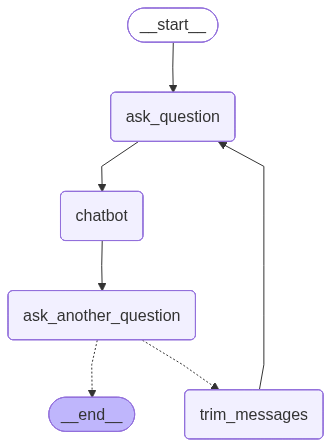

In [26]:
grpah_compiled

In [27]:
grpah_compiled.invoke(MessagesState(message=[] ))


--------> ENTERING ask_question
What is your question ?


 WHAT YEAR IS THIS YEAR?



--------> ENTERING CHATBOT
================================== Ai Message ==================================

What is your question ?
================================ Human Message =================================

WHAT YEAR IS THIS YEAR?
================================== Ai Message ==================================

This year is 2021.

--------> ENTERING ask_another_question
================================== Ai Message ==================================

What is your question ?
================================ Human Message =================================

WHAT YEAR IS THIS YEAR?
================================== Ai Message ==================================

This year is 2021.
Would you like to ask another question (YES/NO) ?


 yes



--------> ENTERING trim_messages:

--------> ENTERING ask_question
================================== Ai Message ==================================

What is your question ?
================================ Human Message =================================

WHAT YEAR IS THIS YEAR?
================================== Ai Message ==================================

This year is 2021.
================================== Ai Message ==================================

Would you like to ask another question (YES/NO) ?
================================ Human Message =================================

yes
What is your question ?


...


--------> ENTERING trim_messages:

--------> ENTERING ask_question
================================== Ai Message ==================================

What is your question ?
================================ Human Message =================================

what happend this year ?
================================== Ai Message ==================================

Here are some notable events that have happened in 2021:

1. The COVID-19 pandemic continued to impact the world, with vaccination efforts ramping up in many countries.
2. The United States inaugurated Joe Biden as the 46th
================================== Ai Message ==================================

Would you like to ask another question (YES/NO) ?
================================ Human Message =================================

yes
What is your question ?


 what day was september 24 this year?



--------> ENTERING CHATBOT
================================== Ai Message ==================================

What is your question ?
================================ Human Message =================================

what happend this year ?
================================== Ai Message ==================================

Here are some notable events that have happened in 2021:

1. The COVID-19 pandemic continued to impact the world, with vaccination efforts ramping up in many countries.
2. The United States inaugurated Joe Biden as the 46th
================================== Ai Message ==================================

Would you like to ask another question (YES/NO) ?
================================ Human Message =================================

yes
================================== Ai Message ==================================

What is your question ?
================================ Human Message =================================

what day was september 24 this year?
==========

 no


{'messages': [AIMessage(content='What is your question ?', additional_kwargs={}, response_metadata={}, id='51e961ad-f3c3-4460-806d-af4e60a06402', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='what happend this year ?', additional_kwargs={}, response_metadata={}, id='76e0de08-3332-4f42-bcf5-f0f9b4293113'),
  AIMessage(content='Here are some notable events that have happened in 2021:\n\n1. The COVID-19 pandemic continued to impact the world, with vaccination efforts ramping up in many countries.\n2. The United States inaugurated Joe Biden as the 46th', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 74, 'total_tokens': 124, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerpri

So we demonstrated that this approach could be very convenient in cases where the subject of the conversation

is frequently mentioned, so that the chatbot knows what you're referring to at any time.

But there's always the concern that conversation details might be lost along the way, and the chatbot

might respond inadequately.

If this is an issue for your program.

Then the next technique might be for you summarizing messages.

We'll dedicate the next lesson to implementing this approach.


Play
